In [27]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

In [2]:
input_dir = Path("./near_road_validation_output")

input_file = (
    input_dir /
    "NearRoad_BASE_LOCUS_hourly_2023.csv"
)

plot_dir = input_dir / "hourly_difference_plots"
plot_dir.mkdir(parents=True, exist_ok=True)


In [17]:
site_order = [
    "Kennedy Expressway",
    "Kingery Expressway",
]


species_units = {
    "NO2": "ppb",
    "PM25_TOT": r"$\mu$g m$^{-3}$",
}

species_titles = {
    "NO2": r"NO$_2$",
    "PM25_TOT": r"PM$_{2.5}$",
}

scenario_labels = {
    "BASE": "EPA Default",
    "LOCUS": "Idling and On-road Activity Modification",
}

scenario_order = [
    "EPA Default",
    "Idling and On-road Activity Modification",
]

In [11]:
if not input_file.exists():
    raise FileNotFoundError(
        f"Input file was not found:\n{input_file}\n\n"
        "Run the near-road validation script first or update "
        "the input_file path."
    )

hourly = pd.read_csv(input_file)

required_columns = [
    "Datetime GMT",
    "OBS",
    "CMAQ",
    "Scenario",
    "Species",
    "Site_ID",
    "Site_Name",
]

missing_columns = [
    column
    for column in required_columns
    if column not in hourly.columns
]

if missing_columns:
    raise ValueError(
        "The input file is missing the following columns: "
        + ", ".join(missing_columns)
    )


In [12]:
hourly["Datetime GMT"] = pd.to_datetime(
    hourly["Datetime GMT"],
    errors="coerce",
    utc=True,
)

hourly["OBS"] = pd.to_numeric(
    hourly["OBS"],
    errors="coerce",
)

hourly["CMAQ"] = pd.to_numeric(
    hourly["CMAQ"],
    errors="coerce",
)

hourly["Scenario_Label"] = hourly["Scenario"].map(
    scenario_labels
).fillna(hourly["Scenario"])

hourly = hourly.dropna(
    subset=[
        "Datetime GMT",
        "OBS",
        "CMAQ",
        "Scenario",
        "Species",
        "Site_Name",
    ]
).copy()

In [13]:
hourly["Datetime Local"] = (
    hourly["Datetime GMT"]
    .dt.tz_convert("America/Chicago")
)

hourly["Local Hour"] = hourly["Datetime Local"].dt.hour

hourly["Month"] = hourly["Datetime Local"].dt.month

hourly["Month Name"] = (
    hourly["Datetime Local"]
    .dt.strftime("%b")
)


# Positive values indicate CMAQ overprediction.
# Negative values indicate CMAQ underprediction.
hourly["Difference"] = hourly["CMAQ"] - hourly["OBS"]

In [18]:
hourly_summary = (
    hourly
    .groupby(
        [
            "Species",
            "Site_ID",
            "Site_Name",
            "Scenario_Label",
            "Local Hour",
        ],
        as_index=False,
    )
    .agg(
        Mean_Difference=("Difference", "mean"),
        Median_Difference=("Difference", "median"),
        Standard_Deviation=("Difference", "std"),
        N=("Difference", "count"),
        Mean_OBS=("OBS", "mean"),
        Mean_CMAQ=("CMAQ", "mean"),
    )
)

hourly_summary["Standard_Error"] = (
    hourly_summary["Standard_Deviation"] /
    np.sqrt(hourly_summary["N"])
)

hourly_summary["CI95_Lower"] = (
    hourly_summary["Mean_Difference"] -
    1.96 * hourly_summary["Standard_Error"]
)

hourly_summary["CI95_Upper"] = (
    hourly_summary["Mean_Difference"] +
    1.96 * hourly_summary["Standard_Error"]
)


# Save the summarized values used in the plots.
summary_file = (
    plot_dir /
    "NearRoad_hourly_difference_summary.csv"
)

hourly_summary.to_csv(
    summary_file,
    index=False,
)

In [38]:
metrics_file = (
    input_dir /
    "NearRoad_BASE_LOCUS_hourly_metrics_four_months.csv"
)

if not metrics_file.exists():
    raise FileNotFoundError(
        f"Four-month metrics file was not found:\n{metrics_file}"
    )

four_month_metrics = pd.read_csv(metrics_file)

four_month_metrics["Scenario_Label"] = (
    four_month_metrics["Scenario"]
    .map(scenario_labels)
    .fillna(four_month_metrics["Scenario"])
)
metric_row = four_month_metrics[
    (four_month_metrics["Species"] == species) &
    (four_month_metrics["Site_Name"] == site_name) &
    (four_month_metrics["Scenario_Label"] == scenario)
].iloc[0]


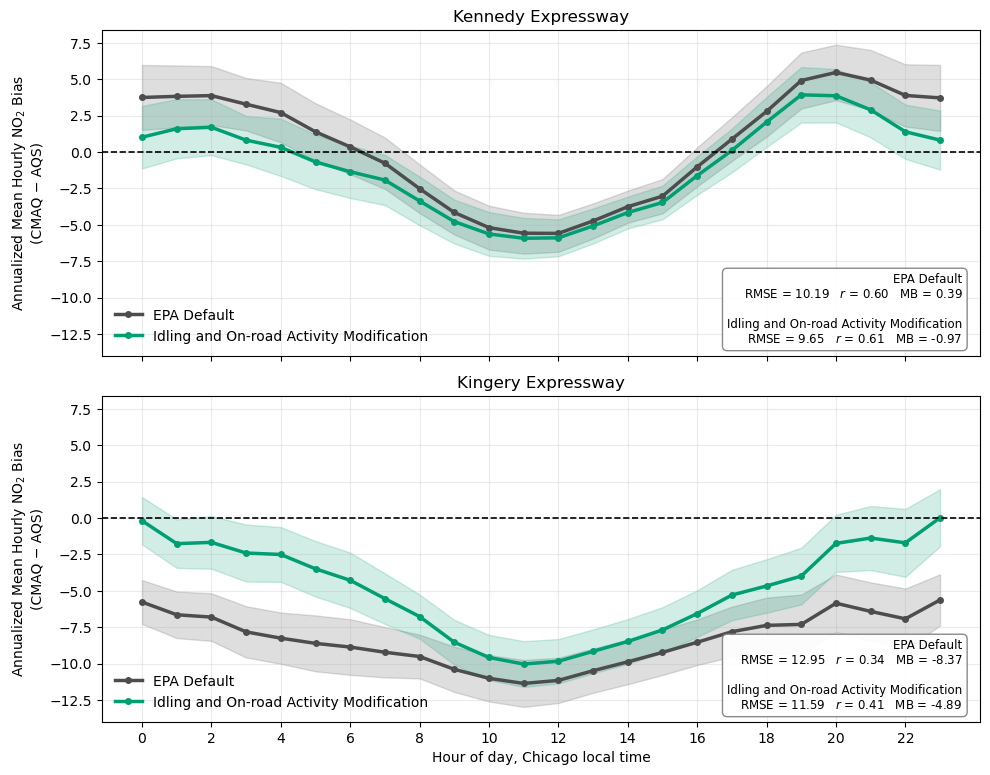

Saved: near_road_validation_output\hourly_difference_plots\NearRoad_NO2_hourly_differences.png


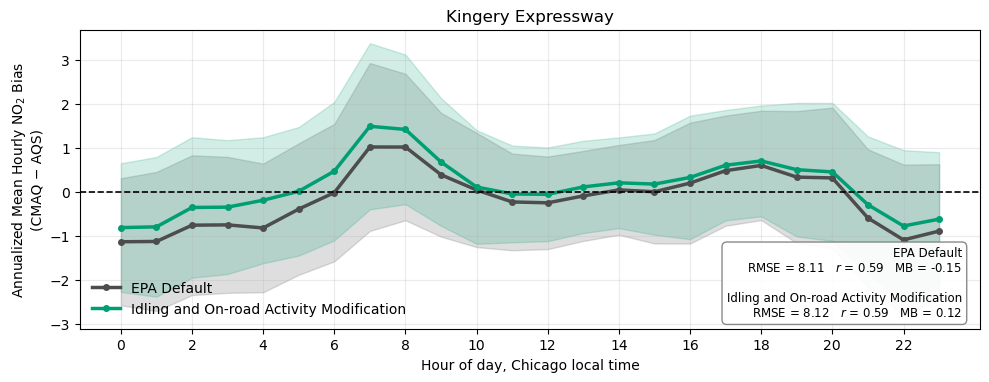

Saved: near_road_validation_output\hourly_difference_plots\NearRoad_PM25_TOT_hourly_differences.png


In [54]:
scenario_colors = {
    "EPA Default": "#4D4D4D",
    "Idling and On-road Activity Modification": "#009E73",
}

available_species = hourly_summary["Species"].unique()

for species in available_species:

    species_data = hourly_summary[
        hourly_summary["Species"] == species
    ].copy()

    available_sites = [
        site
        for site in site_order
        if site in species_data["Site_Name"].unique()
    ]

    if not available_sites:
        print(
            f"No site data available for {species}. Skipping figure."
        )
        continue

    number_sites = len(available_sites)

    fig, axes = plt.subplots(
        nrows=number_sites,
        ncols=1,
        figsize=(10, 4.2 * number_sites),
        sharex=True,
        sharey=True,
    )

    axes = np.atleast_1d(axes)

    for ax, site_name in zip(axes, available_sites):

        site_data = species_data[
            species_data["Site_Name"] == site_name
        ].copy()

        # Reset the statistics text for every station panel
        stats_lines = []

        for scenario in scenario_order:

            scenario_data = site_data[
                site_data["Scenario_Label"] == scenario
            ].sort_values("Local Hour")

            if scenario_data.empty:
                print(
                    f"No plotting data for {species}, "
                    f"{site_name}, {scenario}"
                )
                continue

            color = scenario_colors.get(
                scenario,
                "black",
            )

            ax.plot(
                scenario_data["Local Hour"],
                scenario_data["Mean_Difference"],
                marker="o",
                linewidth=2.5,
                markersize=4,
                color=color,
                label=scenario,
            )

            ax.fill_between(
                scenario_data["Local Hour"],
                scenario_data["CI95_Lower"],
                scenario_data["CI95_Upper"],
                color=color,
                alpha=0.18,
            )

            # Pull the matching four-month hourly statistics
            metric_match = four_month_metrics[
                (four_month_metrics["Species"] == species) &
                (four_month_metrics["Site_Name"] == site_name) &
                (
                    four_month_metrics["Scenario_Label"]
                    == scenario
                )
            ]

            if len(metric_match) == 1:

                metric_row = metric_match.iloc[0]

                stats_lines.append(
                    f"{scenario}\n"
                    f"RMSE = {metric_row['RMSE']:.2f}   "
                    f"$r$ = {metric_row['R']:.2f}   "
                    f"MB = {metric_row['MB']:.2f}"
                )

            elif len(metric_match) == 0:

                print(
                    f"No metric row found for {species}, "
                    f"{site_name}, {scenario}"
                )

            else:

                print(
                    f"Multiple metric rows found for {species}, "
                    f"{site_name}, {scenario}"
                )

        ax.axhline(
            0,
            linewidth=1.2,
            linestyle="--",
            color="black",
        )

        ax.set_title(site_name)

        ax.set_ylabel(
            "Annualized Mean Hourly NO$_2$ Bias\n(CMAQ − AQS)"
        )

        ax.grid(
            alpha=0.25,
        )

        if site_name == "Kennedy Expressway":
            legend_loc = "lower right",
        else:
            legend_loc = "upper right"

        ax.legend(
            #title="Scenario",
            frameon=False,
            loc="lower left",
            )
        # Add exactly one statistics box to this station panel
        if stats_lines:

            stats_text = "\n\n".join(stats_lines)

            ax.text(
                0.98,
                0.03,
                stats_text,
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                fontsize=8.5,
                bbox=dict(
                    facecolor="white",
                    edgecolor="0.5",
                    alpha=0.92,
                    boxstyle="round,pad=0.4",
                ),
            )

    axes[-1].set_xlabel(
        "Hour of day, Chicago local time"
    )

    axes[-1].set_xticks(
        np.arange(0, 24, 2)
    )

    pollutant_title = species_titles.get(
        species,
        species,
    )

#     fig.suptitle(
#         f"Mean hourly {pollutant_title} model bias at "
#         "near-road AQS monitors",
#         fontsize=14,
#         y=0.995,
#     )

    fig.tight_layout(
        rect=[0, 0.035, 1, 0.97]
    )

    output_file = (
        plot_dir /
        f"NearRoad_{species}_hourly_differences.png"
    )

    fig.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print("Saved:", output_file)